### Analytical Frequency Response Analysis

**Difference Equation:** $y[n] = x[n] + 2x[n-1] + x[n-2]$

**Impulse Response:** $h[n] = \delta[n] + 2\delta[n-1] + \delta[n-2]$

**Frequency Response:** $\mathcal{H}(e^{j\omega}) = 1 + 2e^{-j\omega} + e^{-j2\omega}$

**Equivalent Expression:** $\mathcal{H}(e^{j\omega}) = 2e^{-j\omega}[\cos(\omega)+1]$

**Theoretical Magnitude:** $|\mathcal{H}(e^{j\omega})| = 2[\cos(\omega)+1]$

**Theoretical Phase:** $\angle\mathcal{H}(e^{j\omega}) = -\omega$

### Numerical Verification

Maximum magnitude deviation = 8.882e-16
Maximum phase deviation = 7.194e-14 rad
Maximum phase deviation = 4.122e-12 degrees

Theoretical magnitude at ω = 0: 4.000000
Numerical magnitude at ω = 0: 4.000000

Theoretical magnitude at ω = π: 0.000000
Numerical magnitude at ω = π: 0.000000


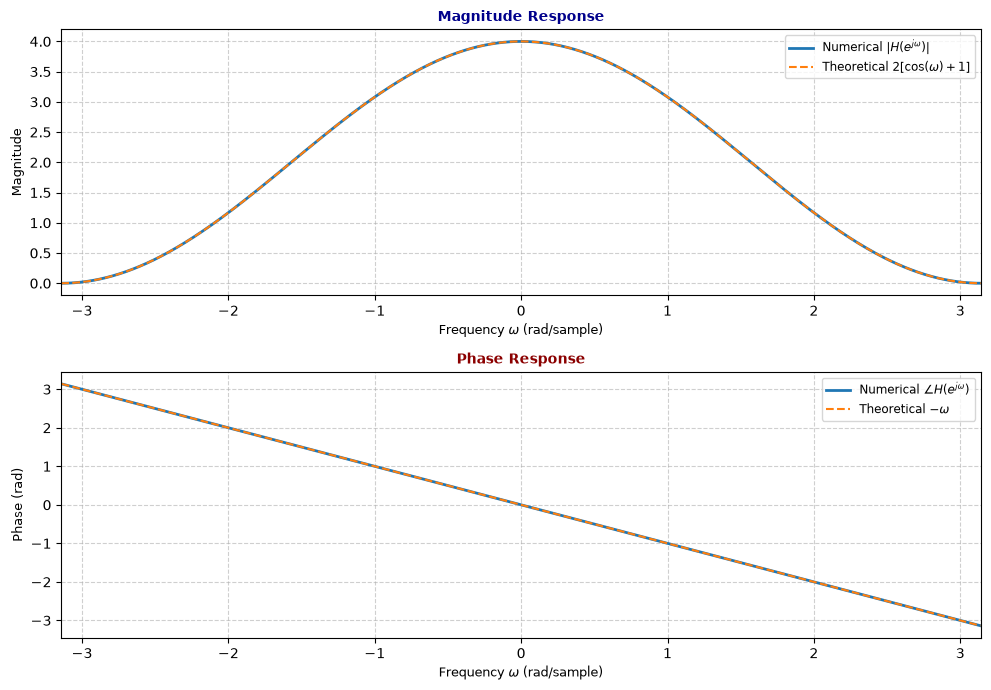

In [3]:
# Notebook: Magnitude and Phase of the Frequency Response
# System: y[n] = x[n] + 2x[n-1] + x[n-2]

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Analytical Frequency Response

display(Markdown("### Analytical Frequency Response Analysis"))
display(Markdown(r"**Difference Equation:** $y[n] = x[n] + 2x[n-1] + x[n-2]$"))
display(Markdown(r"**Impulse Response:** $h[n] = \delta[n] + 2\delta[n-1] + \delta[n-2]$"))
display(Markdown(r"**Frequency Response:** $\mathcal{H}(e^{j\omega}) = "r"1 + 2e^{-j\omega} + e^{-j2\omega}$"))
display(Markdown(r"**Equivalent Expression:** $\mathcal{H}(e^{j\omega}) = "r"2e^{-j\omega}[\cos(\omega)+1]$"))
display(Markdown(r"**Theoretical Magnitude:** $|\mathcal{H}(e^{j\omega})| = " r"2[\cos(\omega)+1]$"))
display(Markdown(r"**Theoretical Phase:** $\angle\mathcal{H}(e^{j\omega}) = -\omega$"))

# Frequency Axis
omega = np.linspace(-np.pi, np.pi, 2001)
# Direct Numerical Frequency Response
H = 1 + 2*np.exp(-1j*omega) + np.exp(-2j*omega)
magnitude_direct = np.abs(H)
phase_direct = np.angle(H)
# Theoretical Magnitude and Phase
magnitude_theoretical = 2*(np.cos(omega) + 1)
phase_theoretical = -omega
# Phase is undefined where the magnitude is zero
valid_phase = magnitude_direct > 1e-10
# Numerical Errors
magnitude_error = np.abs(magnitude_direct - magnitude_theoretical)
max_magnitude_error = np.max(magnitude_error)
phase_error = np.abs(phase_direct[valid_phase] - phase_theoretical[valid_phase])
max_phase_error = np.max(phase_error)
# Numerical Verification
display(Markdown("### Numerical Verification"))
print(f"Maximum magnitude deviation = {max_magnitude_error:.3e}")
print(f"Maximum phase deviation = {max_phase_error:.3e} rad")
print(f"Maximum phase deviation = {np.degrees(max_phase_error):.3e} degrees")
# Additional Verification
print()
print(f"Theoretical magnitude at ω = 0: " f"{2*(np.cos(0) + 1):.6f}")
print(f"Numerical magnitude at ω = 0: " f"{magnitude_direct[len(omega)//2]:.6f}")
print()
print(f"Theoretical magnitude at ω = π: " f"{2*(np.cos(np.pi) + 1):.6f}")
print(f"Numerical magnitude at ω = π: " f"{magnitude_direct[-1]:.6f}")
# Plotting
fig, axes = plt.subplots(2, 1, figsize=(10, 7))
# Magnitude Response
axes[0].plot( omega, magnitude_direct, linewidth=2, label=r'Numerical $|H(e^{j\omega})|$' )
axes[0].plot( omega, magnitude_theoretical, '--', linewidth=1.5, label=r'Theoretical $2[\cos(\omega)+1]$' )
axes[0].set_title('Magnitude Response', fontsize=10, fontweight='bold', color='darkblue')
axes[0].set_xlabel(r'Frequency $\omega$ (rad/sample)', fontsize=9)
axes[0].set_ylabel('Magnitude', fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='upper right', fontsize=8.5)
axes[0].set_xlim(-np.pi, np.pi)
# Phase Response
axes[1].plot( omega[valid_phase], phase_direct[valid_phase], linewidth=2, label=r'Numerical $\angle H(e^{j\omega})$' )
axes[1].plot( omega[valid_phase], phase_theoretical[valid_phase], '--', linewidth=1.5, label=r'Theoretical $-\omega$' )
axes[1].set_title('Phase Response', fontsize=10, fontweight='bold', color='darkred')
axes[1].set_xlabel(r'Frequency $\omega$ (rad/sample)', fontsize=9)
axes[1].set_ylabel('Phase (rad)', fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper right', fontsize=8.5)
axes[1].set_xlim(-np.pi, np.pi)
plt.tight_layout()
plt.show()